# Classification — Comparing Decision Regions

A classifier partitions the feature space: every point in the plane gets assigned a class, whether
or not any data lives there. That partition — the **decision regions** — is the model, far more
completely than any accuracy score is. Two models can score identically and carve the space in
completely different ways.

With two features we can simply draw it. This notebook fits a dozen classifiers to the same 2-D
data and paints what each one does to the whole plane, alongside a second picture: **where the model
is unsure**, measured by the entropy of its predicted probabilities.

## Learning objectives

- Plot the decision regions of a fitted classifier by predicting on a dense grid
- Recognize each family's characteristic boundary: a straight cut, a jagged local one, axis-aligned rectangles
- Use predictive entropy to see where a model is confident and where it hedges
- Explain why a model that is confidently wrong is worse than one that is uncertain
- Compare model families on datasets that are and are not linearly separable

## Background

This notebook assumes the train/test split, the classifier families named below, and Shannon entropy
$H(P) = -\sum_k p_k \log_2 p_k$ from `U1-6_Classify-2_Entropy` — used here on each point's predicted
class probabilities as an uncertainty measure.

`predict_proba` is the method that makes the second panel possible: it returns a probability per
class rather than a single label.

**Prerequisites:** `U1-6_Classify-2_Entropy` (entropy as a measure of uncertainty),
`U1-3_Regression-1_ModelCompare` (the model families, in their regression form)

**Dataset:** none — four synthetic 2-D datasets are available in section 2 via the `choice`
variable.

**References:** https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Tools: entropy and region painting

Two helpers used throughout.

`entropy(x, b)` is the Shannon entropy of a probability vector, in bits when $b = 2$:

$$H(P) = -\sum_{k} p_k \log_2 p_k$$

`visualize_regions` builds a dense grid over the plotting square, asks the model for a prediction at
every grid point, and reshapes the answer into an image. It returns **two** grids:

- `B` — the predicted **class** at each point. This is the decision-region map.
- `S` — the **entropy** of the predicted probability vector at each point. Zero means the model is
  completely certain; the maximum, $\log_2 K$, means it considers all $K$ classes equally likely.

The entropy panel is the one worth studying. A well-behaved classifier is uncertain in a narrow band
along its boundary and confident away from it. A model that is confident everywhere — including
where it is wrong — is the dangerous failure, because nothing in its output signals the mistake.

In [2]:
import math

def entropy( x, b ):
    s = 0
    for p in x:
        if p > 0:
            s += -p*math.log(p,b)
        # end
    # end
    return s
# end

def visualize_regions(model, MAX, nGrid):
    a1 = np.linspace(-MAX, MAX, nGrid)
    a2 = np.linspace(-MAX, MAX, nGrid)

    A1, A2 = np.meshgrid(a1, a2)
    A1 = A1.flatten()
    A2 = A2.flatten()
    A = np.vstack((A1, A2)).T

    # Predict B
    B = model.predict(A)
    B = B.reshape(nGrid, nGrid)
    B = np.flipud(B)

    # Compute entropy for S
    prob_2D = model.predict_proba(A)
    S = np.array([entropy(p, 2) for p in prob_2D])
    S = S.reshape(nGrid, nGrid)
    S = np.flipud(S)

    return B, S
# end

## 2. Create the data

The cell builds **four different datasets**, selected with the `choice` variable at the
top. All four are worth running — they are chosen so that each defeats a different kind of model,
and the whole point of a decision-region plot is to see *how* a model fails:

| `choice` | Generator | Shape | What it tests |
|---|---|---|---|
| 0 | `make_blobs` | Two Gaussian clouds, heavily overlapping at this `cluster_std` | Linearly separable in principle, but the overlap means even a perfect boundary misclassifies. Shows the difference between a *wrong* boundary and an *irreducible* error. |
| 1 | `make_classification` | Informative features with class clusters | The general-purpose case. Note `random_state` is commented out, so this one changes every run — useful for seeing how much the boundary depends on the sample. |
| 2 | `make_moons` | Two interleaving crescents | **Not** linearly separable. A straight boundary cannot work at any cost, so this separates linear models from flexible ones immediately. |
| 3 | `make_circles` | One class ringed around the other | Also not linearly separable, and harder than moons: no single straight cut helps even locally. KNN and trees handle it; logistic regression cannot. |

After generation the data is centred (`X - X.mean(axis=0)`) and `MAX` is set from the largest
absolute coordinate, so every plot below shares one square, symmetric frame.

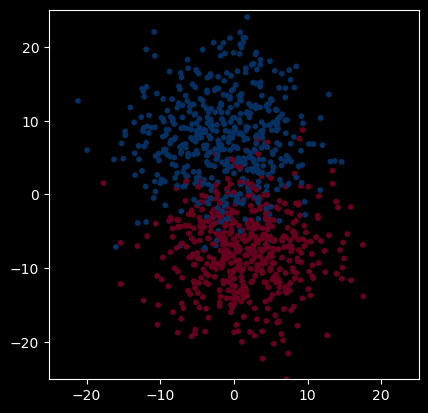

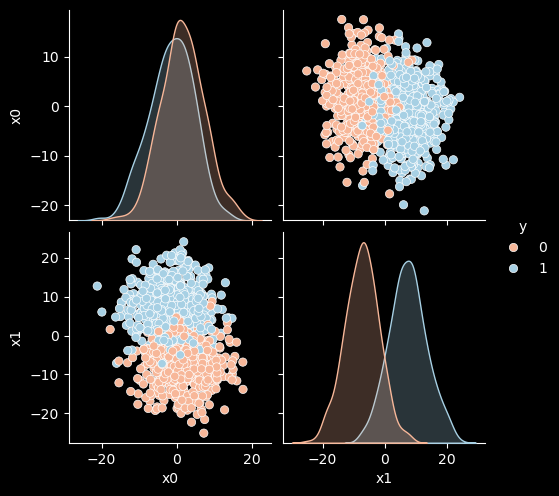

In [3]:
from sklearn.datasets import make_classification, make_blobs, make_moons, make_circles

n_samples = 1000

choice = 0

if   choice == 0:
    X, y = make_blobs(
        n_samples=n_samples,
        n_features=2,
        centers=2,
        cluster_std=6,
        random_state=10
    )
elif choice == 1:
    X, y = make_classification(
        n_samples=n_samples,
        n_features=2,
        n_informative=2,
        n_redundant=0,
        n_clusters_per_class=1,
        n_classes=3,
        #random_state=41
    )
elif choice == 2:
    X, y = make_moons(
        n_samples=n_samples,
        noise=0.2,
        random_state=42
    )
elif choice == 3:
    X, y = make_circles(
        n_samples=n_samples,
        noise=0.1,
        factor=0.5,
        random_state=42
    )
# end

X = X - X.mean(axis=0)

MAX = np.max(np.abs(X))

plt.style.use('dark_background')

plt.scatter(X[:,0], X[:,1], c=y, s=10, cmap="RdBu");
plt.xlim(-MAX,MAX)
plt.ylim(-MAX,MAX)
plt.gca().set_aspect('equal')
plt.show()

df = pd.DataFrame( {"x0":X[:,0], "x1":X[:,1], "y":y} )
sns.pairplot(df, hue='y', palette='RdBu')
plt.show()

## 3. Modeling

### 3.1 Train/test split

`stratify=y` keeps each class's proportion the same in both splits — the classification counterpart
of the plain split used for regression, and it matters as soon as the classes are unbalanced.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)

### 3.2 The model families

Twelve classifiers spanning four families, with several settings each so the effect of complexity is
visible in the pictures:

- **`LogisticRegression`** — fits a linear boundary. Its region map is always **one straight line**
  (a hyperplane in general), so on `make_moons` or `make_circles` it cannot succeed at any setting.
- **`KNeighborsClassifier`** at $k = 1, 5, 10, 50$ — assigns the majority class among the $k$ nearest
  training points. At $k=1$ the regions are a jagged mosaic that carves out individual points; larger
  $k$ smooths the boundary toward something simple.
- **`RandomForestClassifier`** with varied `n_estimators` and `max_leaf_nodes` — trees split on one
  feature at a time, so regions are unions of **axis-aligned rectangles**, visible as staircase
  edges. More leaf nodes means finer steps; more trees means smoother averaged boundaries.
- **`GradientBoostingClassifier`** — also rectangles, but built sequentially on residuals.

Watch for the family signature in the shape of the boundary, not just for which model scores best.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = [
    LogisticRegression(),
    KNeighborsClassifier(n_neighbors=1,   weights='uniform'),
    KNeighborsClassifier(n_neighbors=5,   weights='uniform'),
    KNeighborsClassifier(n_neighbors=10,  weights='uniform'),
    KNeighborsClassifier(n_neighbors=50,  weights='uniform'),
    RandomForestClassifier(n_estimators=10,  max_leaf_nodes=3),
    RandomForestClassifier(n_estimators=10,  max_leaf_nodes=10),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=3),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=10),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=30),
    GradientBoostingClassifier(n_estimators=10,  learning_rate=0.1, max_leaf_nodes=3),
    GradientBoostingClassifier(n_estimators=10,  learning_rate=0.1, max_leaf_nodes=10),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
]

### 3.3 Fit and paint

For each model: fit, score, then draw three panels — training data over the regions, test data over
the same regions, and the entropy map.

Read them in this order. First, **does the boundary shape suit the data?** A straight line over two
crescents is a shape mismatch no tuning fixes. Second, **compare the training and test panels** —
identical regions, different points, so any test point on the wrong side is a visible error. Third,
**check the entropy panel**: the uncertain band should hug the boundary. A KNN at $k=1$ produces
entropy 0 almost everywhere, which is not confidence but an artifact — with one neighbour the
predicted probability is always 0 or 1, so the model literally cannot express doubt.

LogisticRegression()


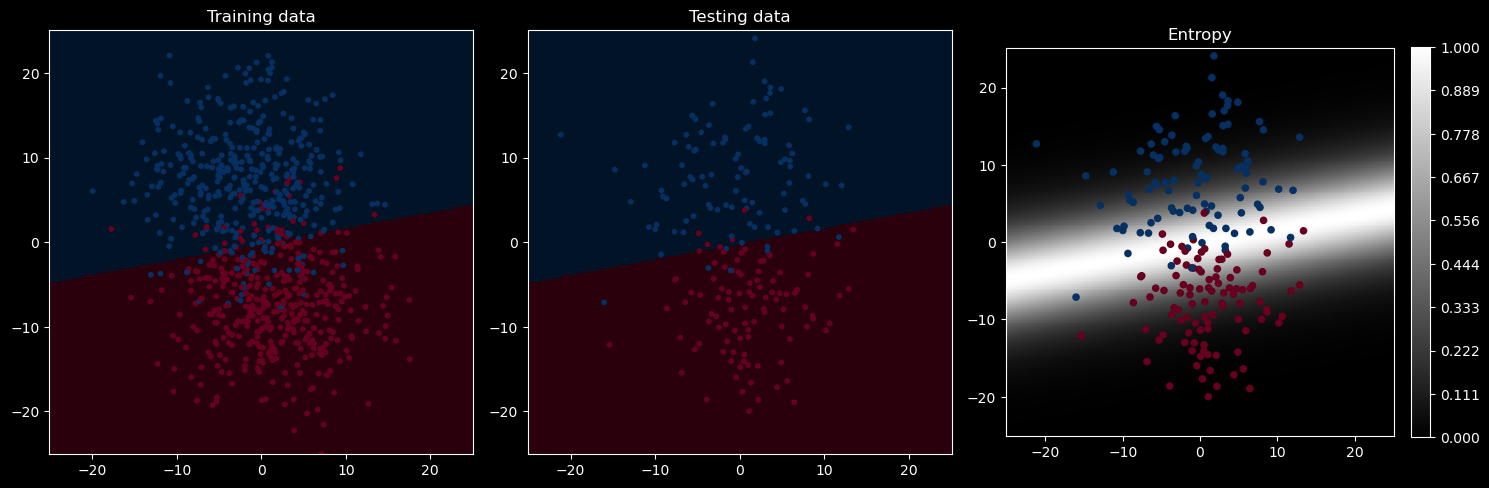

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       100
           1       0.93      0.93      0.93       100

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200



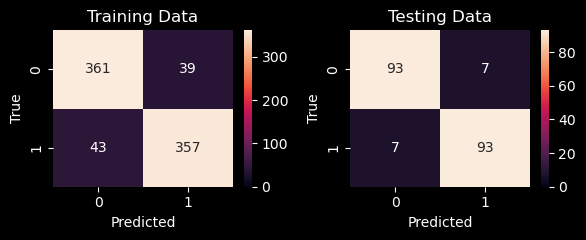

KNeighborsClassifier(n_neighbors=1)


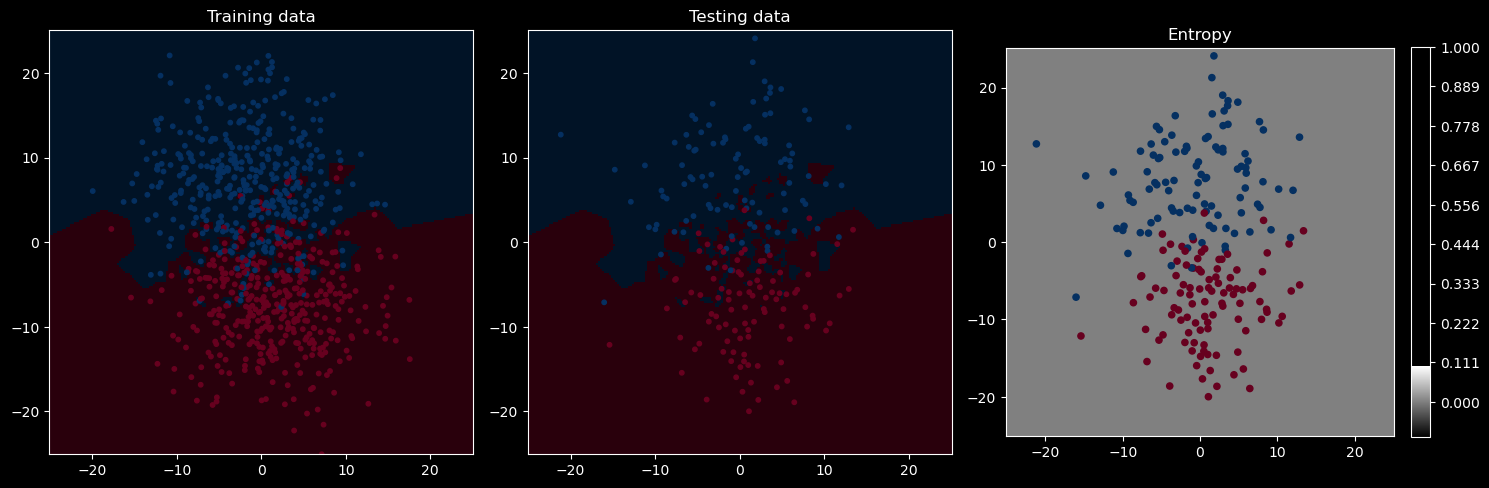

              precision    recall  f1-score   support

           0       0.88      0.90      0.89       100
           1       0.90      0.88      0.89       100

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200



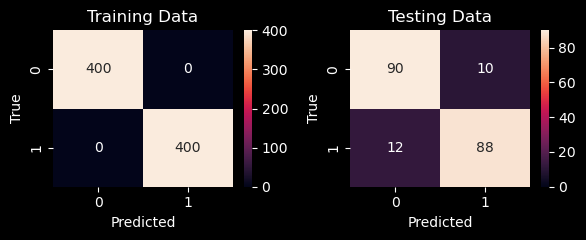

KNeighborsClassifier()


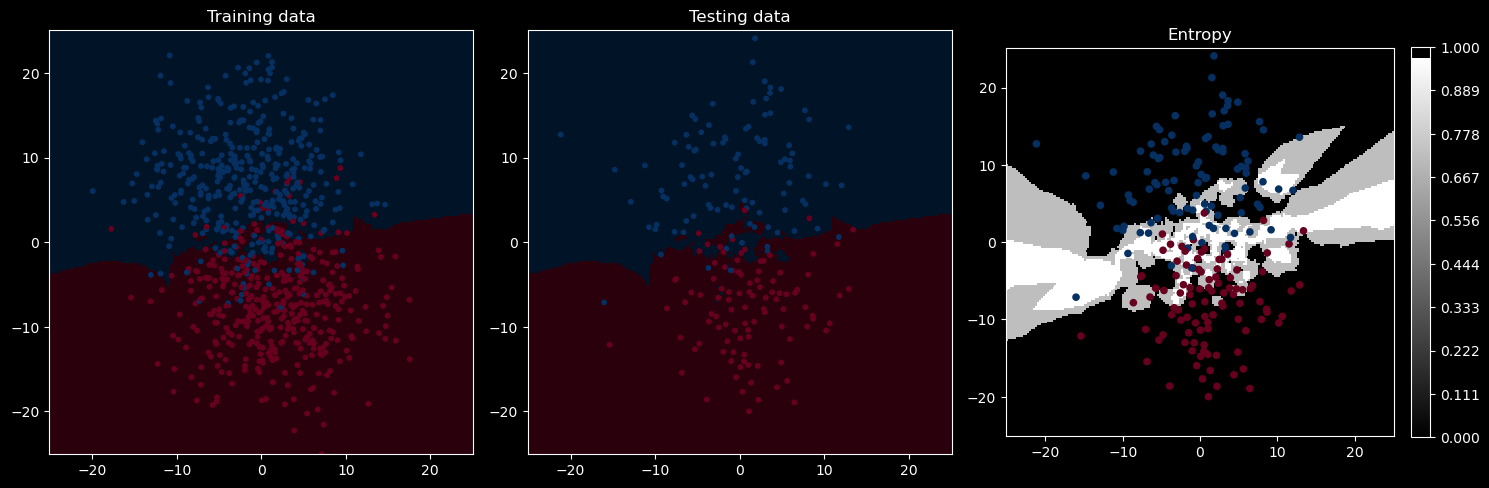

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       100
           1       0.92      0.90      0.91       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200



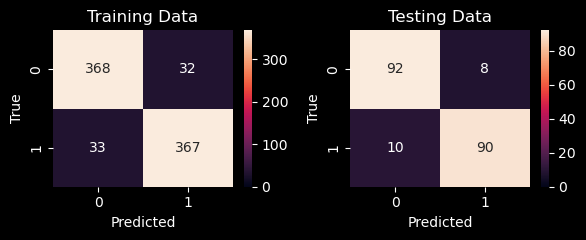

KNeighborsClassifier(n_neighbors=10)


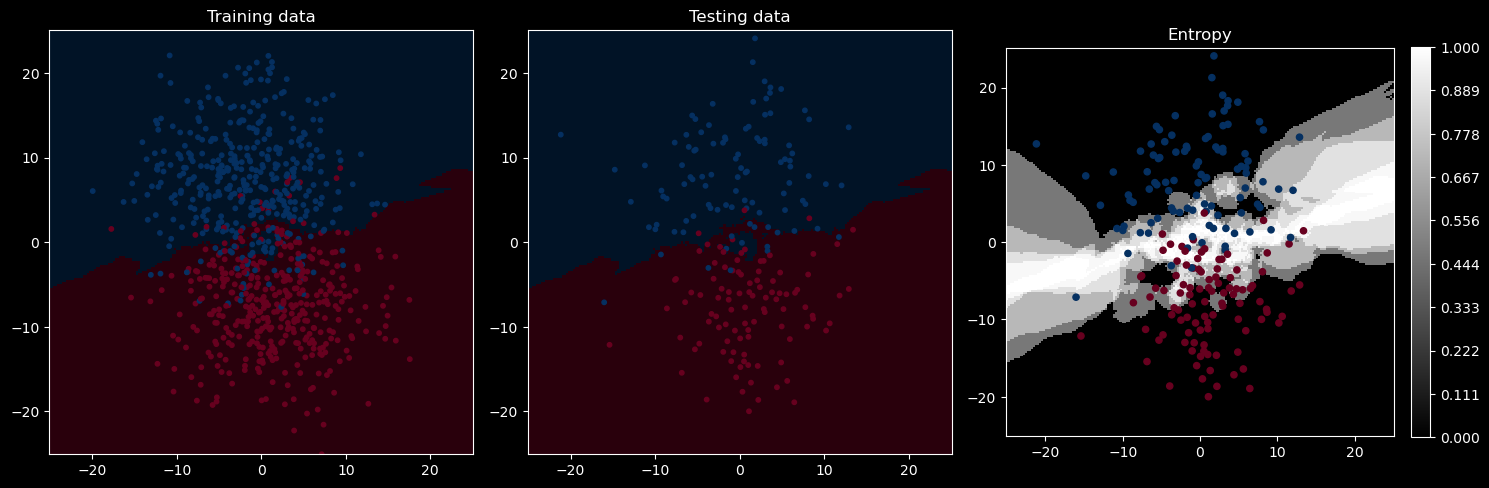

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       100
           1       0.92      0.88      0.90       100

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



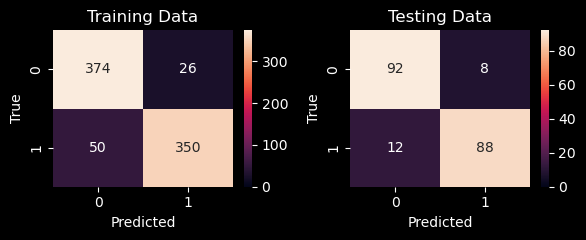

KNeighborsClassifier(n_neighbors=50)


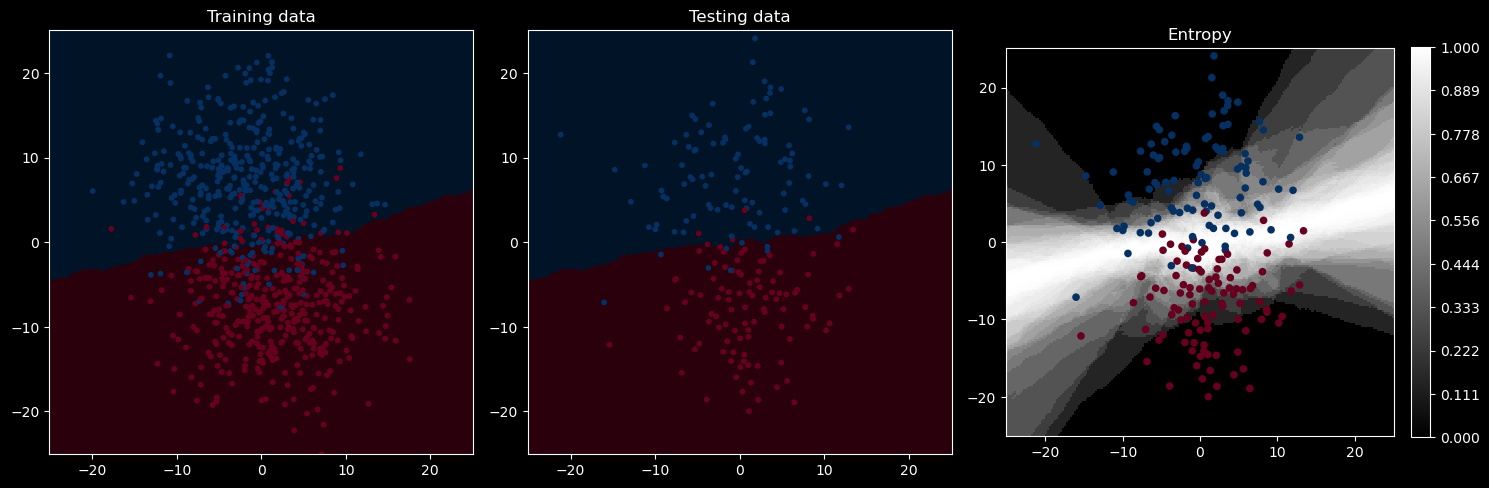

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       100
           1       0.94      0.92      0.93       100

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200



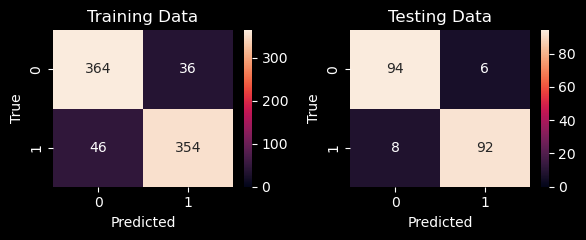

RandomForestClassifier(max_leaf_nodes=3, n_estimators=10)


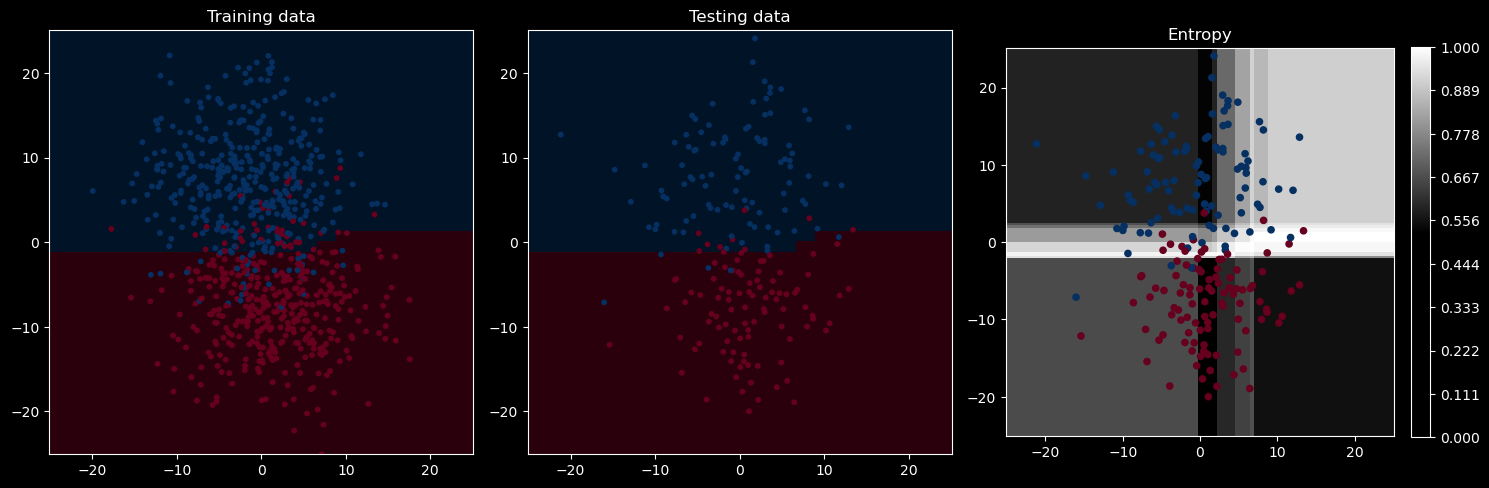

              precision    recall  f1-score   support

           0       0.95      0.89      0.92       100
           1       0.90      0.95      0.92       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200



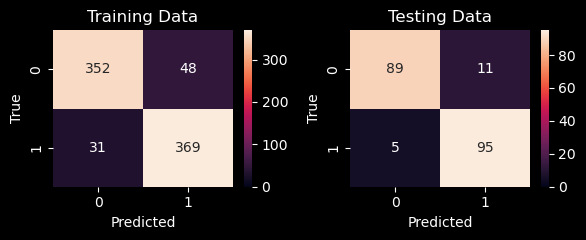

RandomForestClassifier(max_leaf_nodes=10, n_estimators=10)


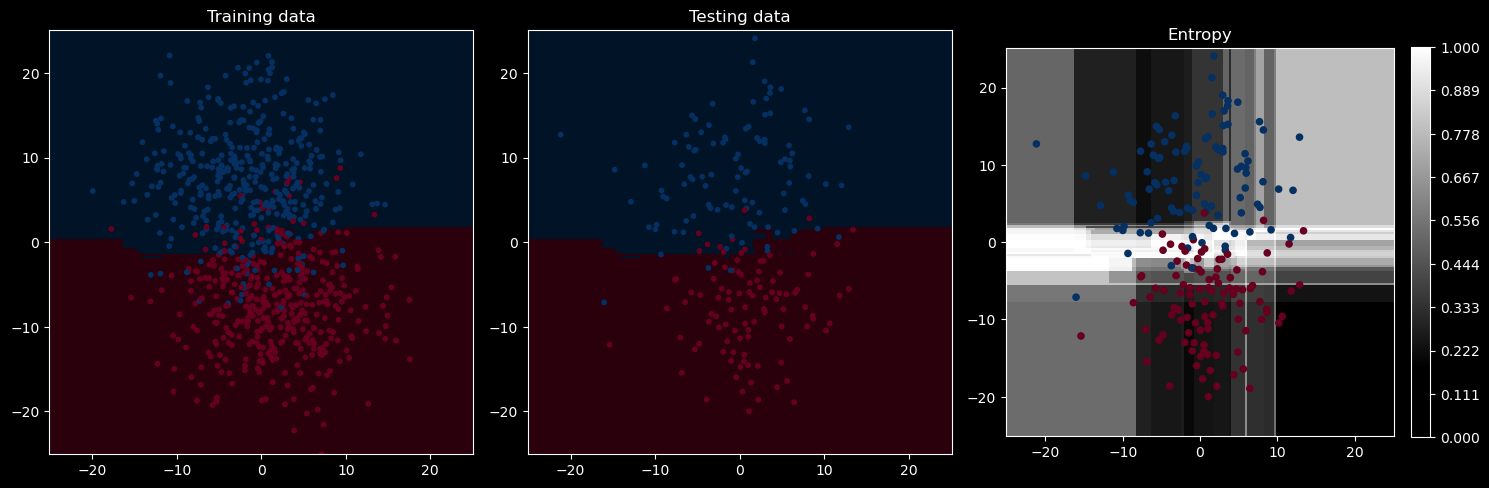

              precision    recall  f1-score   support

           0       0.94      0.90      0.92       100
           1       0.90      0.94      0.92       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200



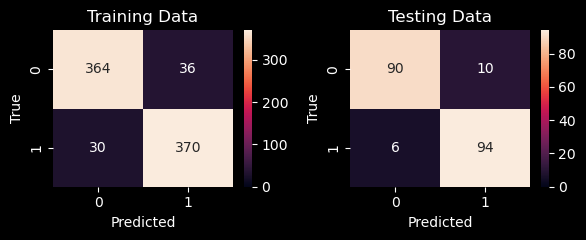

RandomForestClassifier(max_leaf_nodes=3)


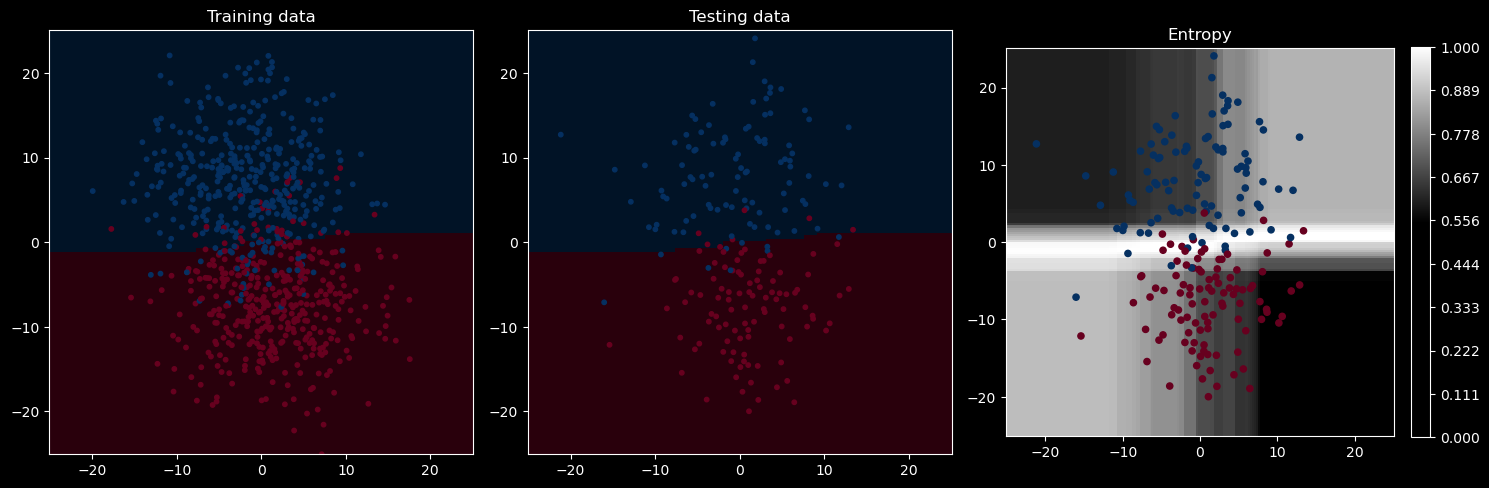

              precision    recall  f1-score   support

           0       0.91      0.94      0.93       100
           1       0.94      0.91      0.92       100

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.92       200
weighted avg       0.93      0.93      0.92       200



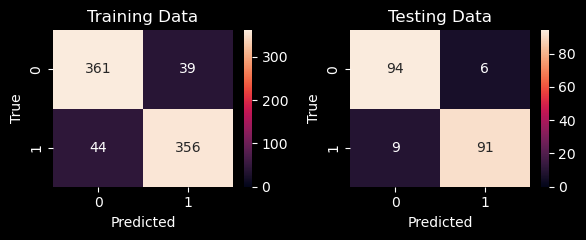

RandomForestClassifier(max_leaf_nodes=10)


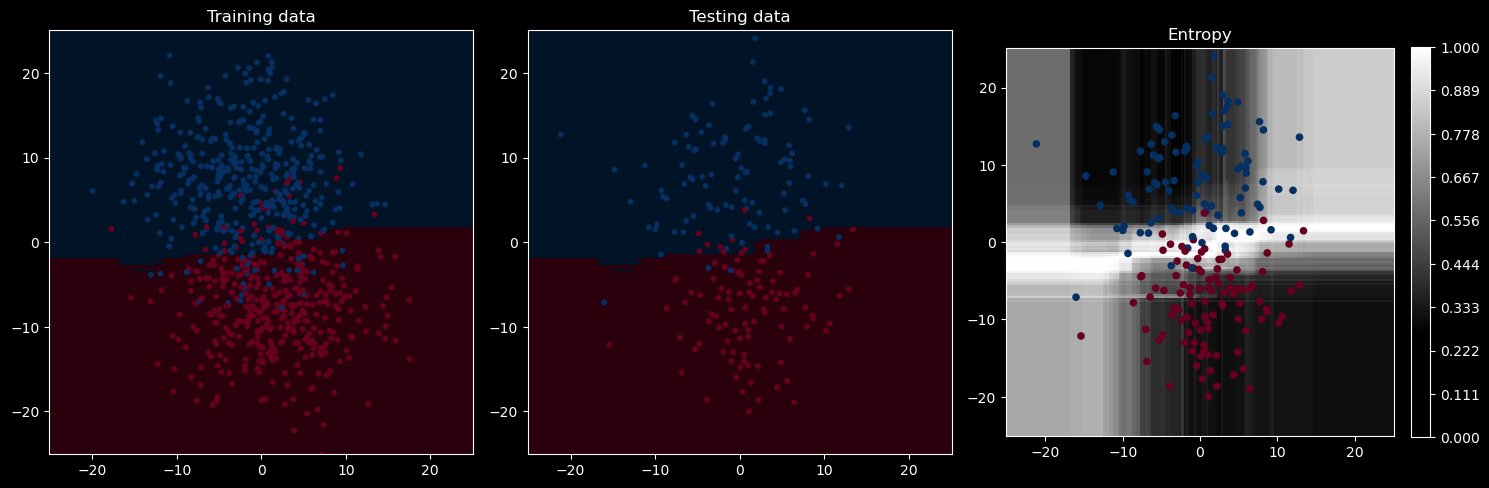

              precision    recall  f1-score   support

           0       0.93      0.90      0.91       100
           1       0.90      0.93      0.92       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.91       200
weighted avg       0.92      0.92      0.91       200



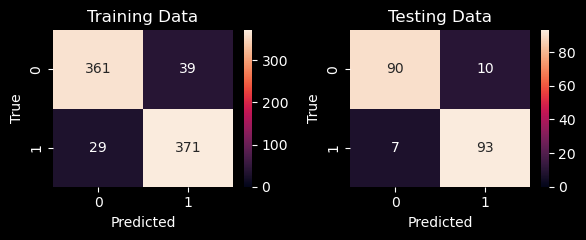

RandomForestClassifier(max_leaf_nodes=30)


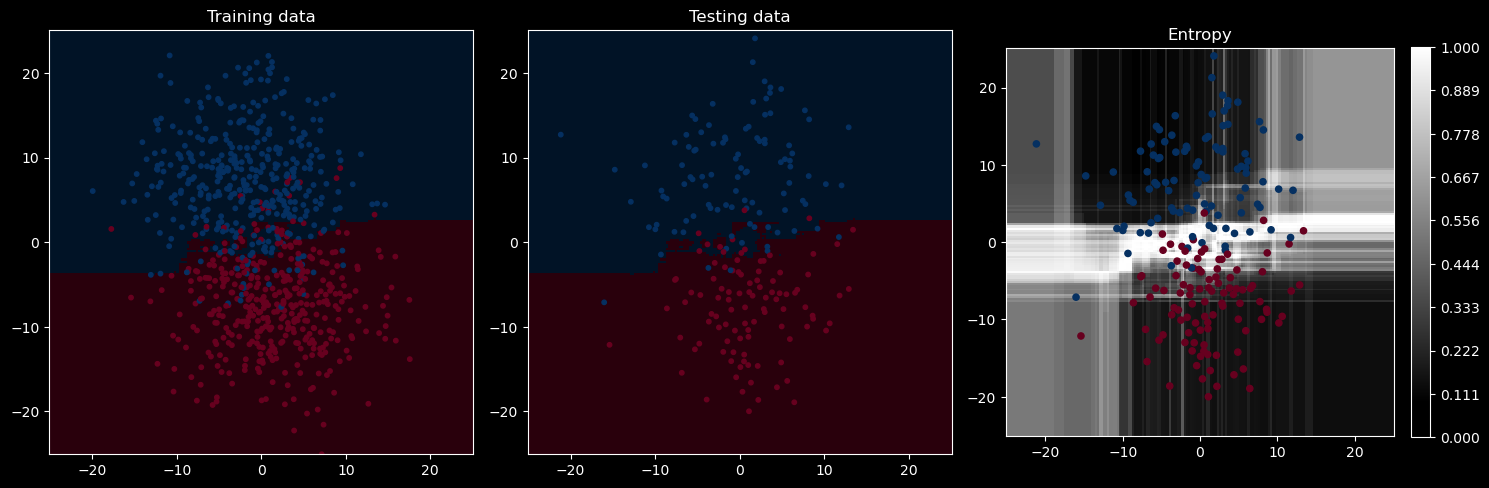

              precision    recall  f1-score   support

           0       0.92      0.92      0.92       100
           1       0.92      0.92      0.92       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200



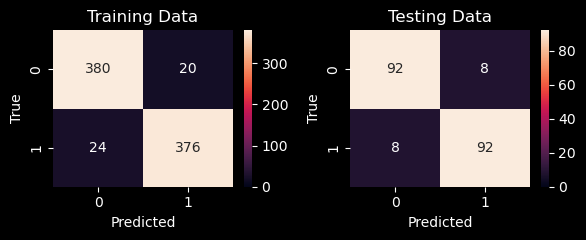

GradientBoostingClassifier(max_leaf_nodes=3, n_estimators=10)


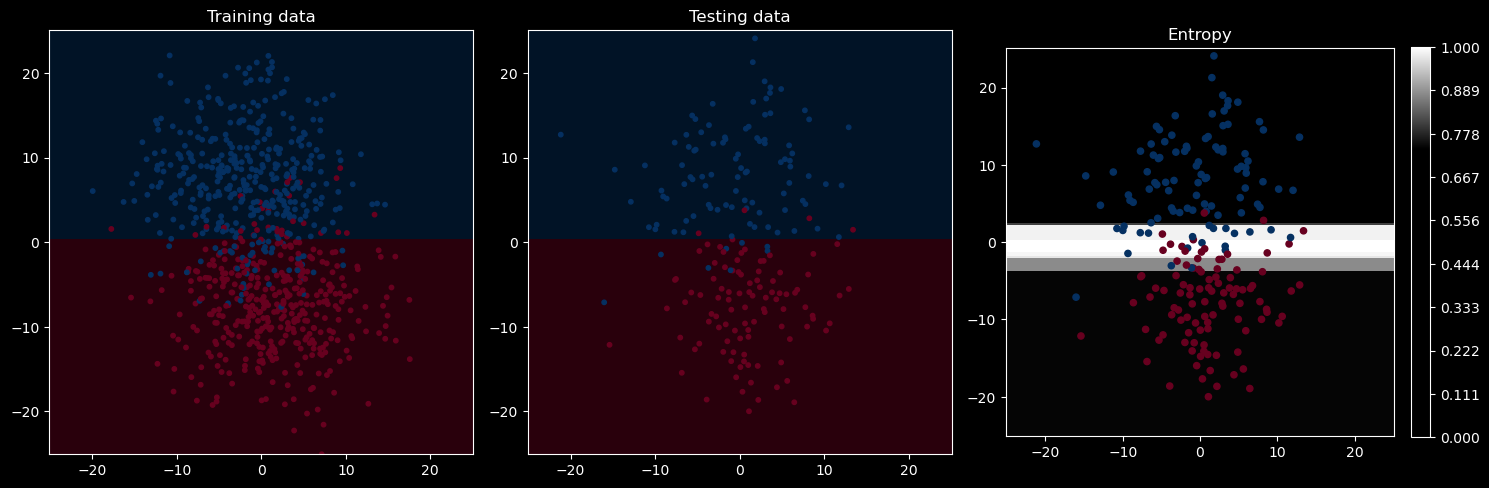

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       100
           1       0.96      0.92      0.94       100

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200



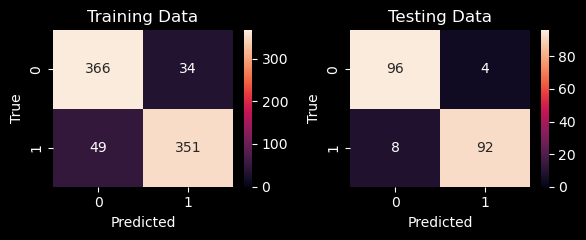

GradientBoostingClassifier(max_leaf_nodes=10, n_estimators=10)


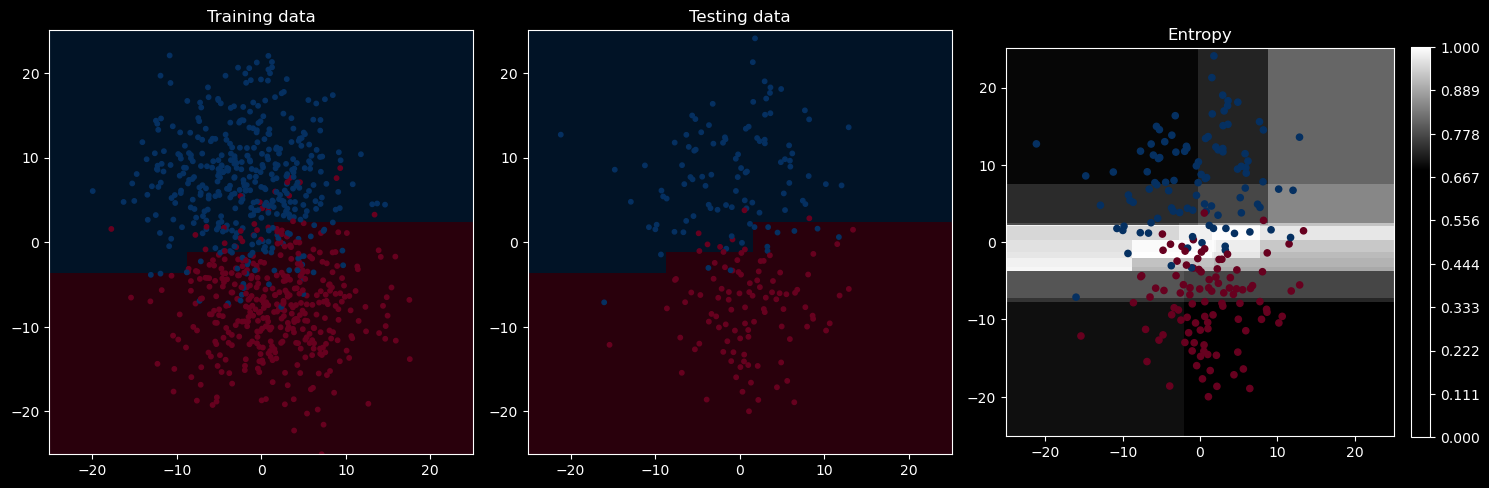

              precision    recall  f1-score   support

           0       0.89      0.89      0.89       100
           1       0.89      0.89      0.89       100

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200



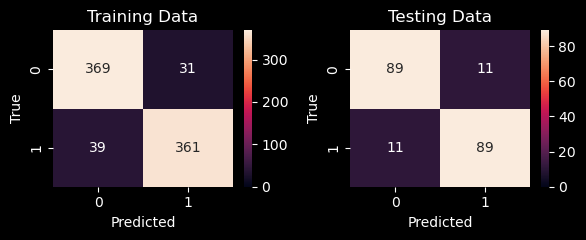

GradientBoostingClassifier(max_leaf_nodes=3)


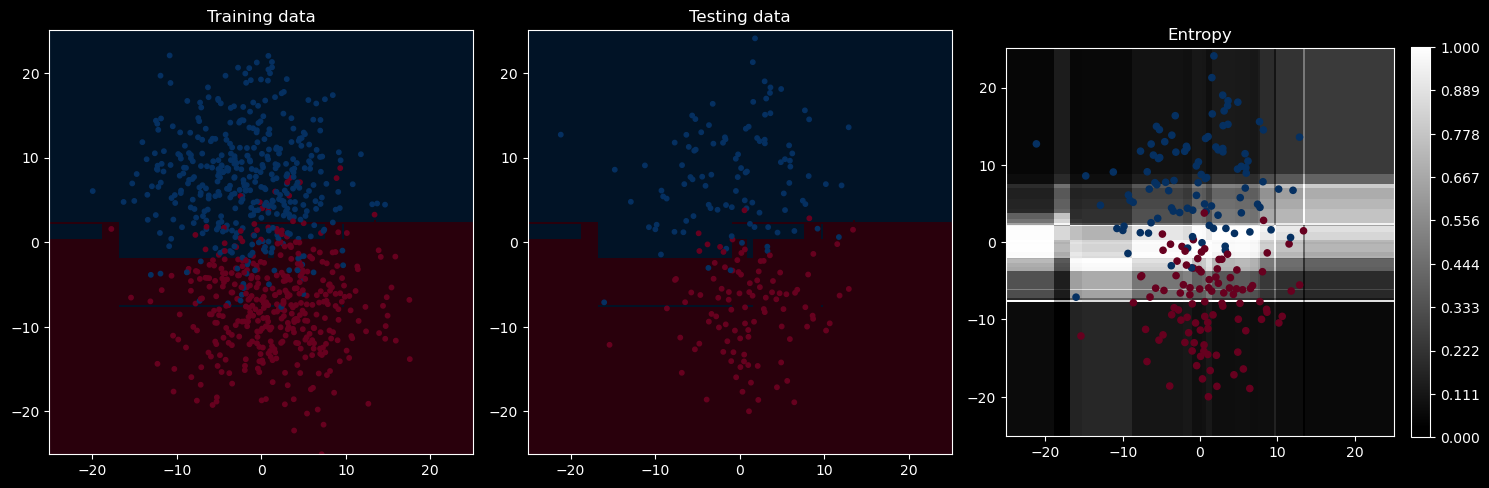

              precision    recall  f1-score   support

           0       0.91      0.93      0.92       100
           1       0.93      0.91      0.92       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200



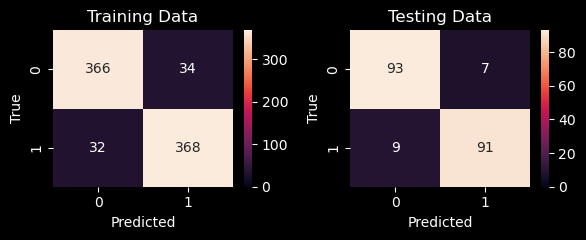

GradientBoostingClassifier(max_leaf_nodes=10)


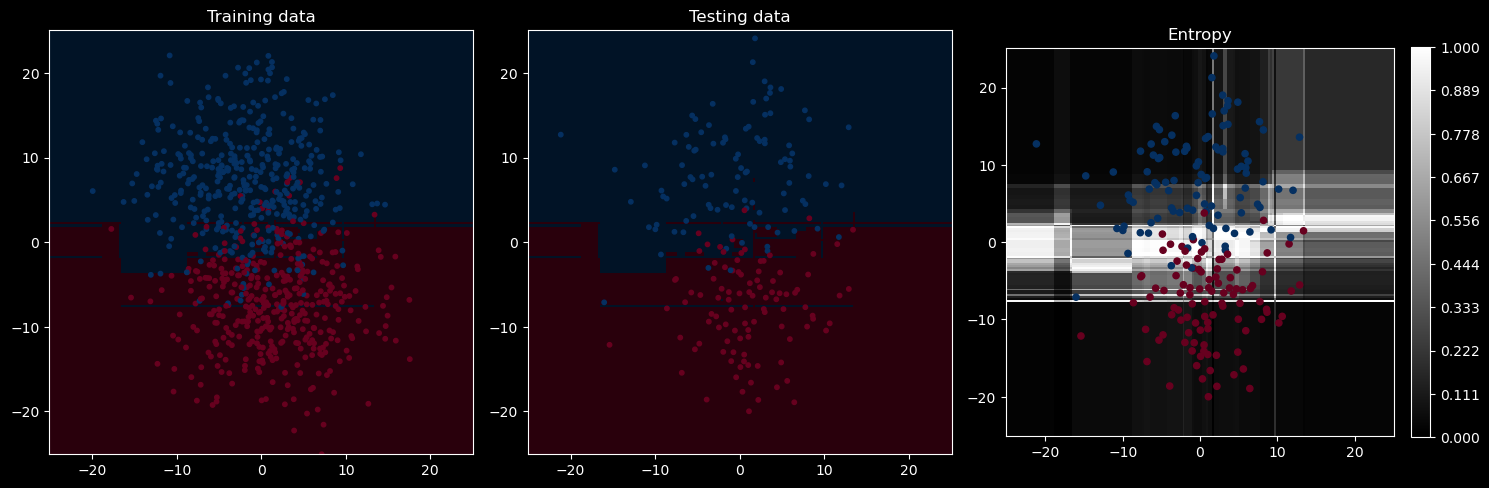

              precision    recall  f1-score   support

           0       0.91      0.89      0.90       100
           1       0.89      0.91      0.90       100

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



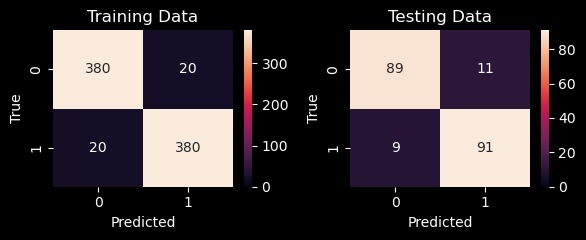

In [6]:
from sklearn.metrics import classification_report, confusion_matrix

for m in models:
    m.fit(X_train, y_train)
    y_train_pred = m.predict(X_train).astype(int)
    y_test_pred = m.predict(X_test).astype(int)
    
    print(m)

    B, S = visualize_regions(m, MAX, 200)
    
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,5))
    
    extent = [-MAX,MAX,-MAX,MAX]
    
    cmap = "RdBu"
    axes[0].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
    axes[0].scatter(X_train[:,0], X_train[:,1], c=y_train, s=10, cmap=cmap);
    axes[0].set_aspect('equal')
    axes[0].set_title('Training data');
    
    axes[1].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
    axes[1].scatter(X_test[:,0], X_test[:,1], c=y_test, s=10, cmap=cmap);
    axes[1].set_aspect('equal')
    axes[1].set_title('Testing data');
    
    im = axes[2].imshow(S, interpolation='none', extent=extent,cmap='gray')
    axes[2].scatter(X_test[:,0], X_test[:,1], c=y_test, s=20, cmap=cmap);
    axes[2].set_aspect('equal')
    axes[2].set_title('Entropy')
    cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    cbar.set_ticks(np.linspace(0, math.log(y.max()+1,2), 10))

    plt.tight_layout()
    plt.show()
    
    print(classification_report(y_test, y_test_pred))

    # Compute confusion matrices
    conf_matrix_train = confusion_matrix(y_train, y_train_pred)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred)
    
    # Create subplots for side-by-side visualization
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.5))
    
    # Plot confusion matrix for training data
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='g', ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")
    
    # Plot confusion matrix for test data
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='g', ax=axes[1])
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")
    
    # Show the plots
    plt.tight_layout()
    plt.show()
# end

## 4. Review

- **A classifier is a partition of the whole feature space**, not just a score. Drawing it shows what
  the model actually learned.
- **Each family has a boundary signature**: logistic regression a single straight cut, KNN a jagged
  local mosaic, trees and forests axis-aligned rectangles.
- **Shape mismatch cannot be tuned away.** No setting of a linear model separates `make_moons` or
  `make_circles`.
- **Entropy shows where the model hedges.** A healthy classifier is uncertain in a narrow band along
  the boundary; confident-everywhere is a warning, and KNN at $k=1$ produces false confidence by
  construction.
- **The training and test panels share the same regions**, so the difference between them is purely
  which points landed where — the clearest possible view of generalization.